In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
import anndata as an
import scanpy as sc
import scanpy.external as sce
import h5py
import scipy
from scipy.stats import pearsonr
from scipy import stats
from scipy.spatial.distance import cdist
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm
import re
import matplotlib.colors as mcolors
import networkx as nx
from itertools import combinations
import json
import random
from adjustText import adjust_text

sc.settings.verbosity = 2

# Load in TF-associated networks

In [2]:
# MYOD1
path1 = "/scratch/indikar_root/indikar1/jrcwycy/HYB/HWG/MYOD_network_1storder_300.csv"
mdf = pd.read_csv(path1, index_col=0)
print(mdf.shape)
display(mdf.head())


# PRRX1
path2 = "/scratch/indikar_root/indikar1/jrcwycy/HYB/HWG/PRRX1_network_1storder_300.csv"
pdf = pd.read_csv(path2, index_col=0)
print(pdf.shape)
display(pdf.head())

(545, 545)


,MYOD1,CD99,KDM1A,PDK4,CALCR,HOXA11,MEOX1,CREBBP,SOX8,IFRD1,...,INS,ENSG00000255071,EID1,SCX,DUX4,PECAM1,MYMX,MYH4,H3-7,DACH1
MYOD1,0,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
CD99,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,1,0,0,0,0
KDM1A,1,0,1,1,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,1,0
PDK4,1,0,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
CALCR,1,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


(196, 196)


,PRRX1,COPZ2,TFAP2B,METTL13,DCN,SNAI2,VIM,CD44,CDH1,PHF23,...,COL5A2,POU5F1,VGLL3,EBF2,TWIST2,BGLAP,FOXD1,HOXB7,SCX,GTF2I
PRRX1,0,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
COPZ2,1,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
TFAP2B,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
METTL13,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DCN,1,0,0,0,0,1,1,1,1,0,...,1,0,0,0,0,1,0,0,1,0


## Make graphs

In [3]:
# MYOD1
GM = nx.from_pandas_adjacency(mdf, create_using=nx.Graph) # keeps self-loops
GM.remove_edges_from(nx.selfloop_edges(GM)) # remove self-loops

print(f"MYOD1:\nN nodes: {GM.number_of_nodes()}\nN edges: {GM.number_of_edges()}")

n_edges = GM.number_of_edges()
n_nodes = GM.number_of_nodes()

density = (2 * n_edges) / (n_nodes * (n_nodes - 1))
print(f"Graph density: {density:.4f}")

print(f'\nIs connected? {nx.is_connected(GM)}')
print(f'N connected components: {nx.number_connected_components(GM)}')
print(f'Largest connected components has {len(max(nx.connected_components(GM), key=len))} nodes\n')



# PRRX1
GP = nx.from_pandas_adjacency(pdf, create_using=nx.Graph) # keeps self-loops
GP.remove_edges_from(nx.selfloop_edges(GP)) # remove self-loops

print(f"\nPRRX1:\nN nodes: {GP.number_of_nodes()}\nN edges: {GP.number_of_edges()}")

n_edges = GP.number_of_edges()
n_nodes = GP.number_of_nodes()

density = (2 * n_edges) / (n_nodes * (n_nodes - 1))
print(f"Graph density: {density:.4f}")

print(f'\nIs connected? {nx.is_connected(GP)}')
print(f'N connected components: {nx.number_connected_components(GP)}')
print(f'Largest connected components has {len(max(nx.connected_components(GP), key=len))} nodes')



## get gene lists for 1st order genes
myod_nodes = list(GM.nodes())
prrx_nodes = list(GP.nodes())

MYOD1:
N nodes: 545
N edges: 29898
Graph density: 0.2017

Is connected? True
N connected components: 1
Largest connected components has 545 nodes


PRRX1:
N nodes: 196
N edges: 4055
Graph density: 0.2122

Is connected? True
N connected components: 1
Largest connected components has 196 nodes


In [4]:
## get gene lists for 1st order genes
myod_nodes = list(GM.nodes())
print(len(myod_nodes))

prrx_nodes = list(GP.nodes())
print(len(prrx_nodes))

545
196


# Load in adata

In [5]:
%%time
path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups_v2.h5ad"
adata = sc.read_h5ad(path)
sc.logging.print_memory_usage()
adata

Memory usage: current 2.43 GB, difference +2.43 GB
CPU times: user 564 ms, sys: 1.96 s, total: 2.52 s
Wall time: 7.12 s


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/anndata/logging.py:57: FutureWarning: The specified parameters ('newline',) are no longer positional. Please specify them like `newline=False`
  print(format_memory_usage(get_memory_usage(), msg, newline))


AnnData object with n_obs × n_vars = 16296 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'st

In [6]:
# Load TFs
fpath = "../../resources/HumanTF_v_1.01.csv"

tdf = pd.read_csv(fpath)

tdf = tdf[['HGNC symbol', 'Is TF?']]
tdf = tdf.rename(columns={'HGNC symbol': 'gene_name', 'Is TF?': 'is_tf'})
tdf = tdf[tdf['is_tf'] == 'Yes']
tdf = tdf.drop_duplicates(subset='gene_name')
display(tdf.head())

# extract unique TFs
tf_list = tdf['gene_name'].unique()
print(len(tf_list))

tf_list = [g for g in tf_list if g in adata.var_names]

print(len(tf_list))

,gene_name,is_tf
0,TFAP2A,Yes
1,TFAP2B,Yes
2,TFAP2C,Yes
3,TFAP2D,Yes
4,TFAP2E,Yes


1639
1358


In [7]:
conditions_to_keep = ['Control', 'siPRRX1']

fdata = adata[adata.obs['pooled_condition'].isin(conditions_to_keep), :].copy()
print(fdata.shape)

(10585, 25126)


In [8]:
# filter genes
fdata.X = fdata.layers['raw_counts'].copy()

sc.pp.filter_genes(fdata, min_counts=10) # param used for original processing

sc.pp.normalize_total(fdata, target_sum=1e4)
fdata.layers['CP10K'] = fdata.X.copy()

sc.pp.log1p(fdata)
fdata.layers['log_norm_new'] = fdata.X.copy()
fdata

filtered out 2257 genes that are detected in less than 10 counts
normalizing counts per cell
    finished (0:00:00)


AnnData object with n_obs × n_vars = 10585 × 22869
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'st

# Detected genes

In [9]:
### Which genes are present in adata?
# MYOD1
gene_names = set(fdata.var_names)
gene_ids = set(fdata.var['gene_id'])

myod_genes = [
    g for g in myod_nodes
    if (g.startswith('ENSG') and g in gene_ids) or
       (not g.startswith('ENSG') and g in gene_names)
]

missing_myod_genes = list(set(myod_nodes) - set(myod_genes))

print(f"N myod nodes in fdata: {len(myod_genes)}")
print(f"{len(missing_myod_genes)} genes not detected.\n")


# PRRX1
prrx_genes = [
    g for g in prrx_nodes
    if (g.startswith('ENSG') and g in gene_ids) or
       (not g.startswith('ENSG') and g in gene_names)
]

missing_prrx_genes = list(set(prrx_nodes) - set(prrx_genes))

print(f"N prrx1 nodes in fdata: {len(prrx_genes)}")
print(f"{len(missing_prrx_genes)} genes not detected.")

N myod nodes in fdata: 425
120 genes not detected.

N prrx1 nodes in fdata: 176
20 genes not detected.


In [10]:
### genes expressed in greater than 10% of cells in either condition
pct_exp_thresh = 0.10

print(f"Nodes (genes) expressed in ≥ {pct_exp_thresh*100:.0f}% of cells in either condition...")

## --------- MYOD1 genes ---------
# Boolean matrix: cells × genes
fdata.X = fdata.layers['raw_counts'].copy()

X = fdata[:, myod_genes].X > 0

# Convert to dense if needed
if not isinstance(X, np.ndarray):
    X = X.toarray()

df = pd.DataFrame(X, index=fdata.obs['pooled_condition'], columns=myod_genes)

# Compute fraction per condition
frac_by_condition = df.groupby(level=0, observed=True).mean()

# Keep genes passing threshold in ANY condition
myod_genes_robust = frac_by_condition.columns[(frac_by_condition >= pct_exp_thresh).any(axis=0)].tolist()
print(f"\nN MYOD1 genes: {len(myod_genes_robust)}")
print(f"% of detected nodes: {(len(myod_genes_robust) / len(myod_genes))*100:.1f}%")
print(f"% of total nodes: {(len(myod_genes_robust) / len(myod_nodes))*100:.1f}%")


## --------- PRRX1 genes ---------
X = fdata[:, prrx_genes].X > 0

# Convert to dense if needed
if not isinstance(X, np.ndarray):
    X = X.toarray()

df = pd.DataFrame(X, index=fdata.obs['pooled_condition'], columns=prrx_genes)

# Compute fraction per condition
frac_by_condition = df.groupby(level=0, observed=True).mean()

# Keep genes passing threshold in ANY condition
prrx_genes_robust = frac_by_condition.columns[(frac_by_condition >= pct_exp_thresh).any(axis=0)].tolist()
print(f"\nN PRRX1 genes: {len(prrx_genes_robust)}")
print(f"% of detected nodes: {(len(prrx_genes_robust) / len(prrx_genes))*100:.1f}%")
print(f"% of total nodes: {(len(prrx_genes_robust) / len(prrx_nodes))*100:.1f}%")

Nodes (genes) expressed in ≥ 10% of cells in either condition...

N MYOD1 genes: 257
% of detected nodes: 60.5%
% of total nodes: 47.2%

N PRRX1 genes: 123
% of detected nodes: 69.9%
% of total nodes: 62.8%


# Build baseline subgraphs

In [11]:
# Baseline
print("Baseline subgraphs...")

BGM = GM.subgraph(myod_genes_robust).copy()
n_edges = BGM.number_of_edges()
n_nodes = BGM.number_of_nodes()
print(f"\nMYOD1 - N nodes: {n_nodes}, N edges: {n_edges}")
density = (2 * n_edges) / (n_nodes * (n_nodes - 1))
print(f"Graph density: {density:.4f}")
print(f'Is connected? {nx.is_connected(BGM)}')
print(f'N connected components: {nx.number_connected_components(BGM)}')
print(f'Largest connected components has {len(max(nx.connected_components(BGM), key=len))} nodes')


BGP = GP.subgraph(prrx_genes_robust).copy()
n_edges = BGP.number_of_edges()
n_nodes = BGP.number_of_nodes()
print(f"\nPRRX1 - N nodes: {n_nodes}, N edges: {n_edges}")
density = (2 * n_edges) / (n_nodes * (n_nodes - 1))
print(f"Graph density: {density:.4f}")
print(f'Is connected? {nx.is_connected(BGP)}')
print(f'N connected components: {nx.number_connected_components(BGP)}')
print(f'Largest connected components has {len(max(nx.connected_components(BGP), key=len))} nodes')

Baseline subgraphs...

MYOD1 - N nodes: 257, N edges: 8745
Graph density: 0.2658
Is connected? True
N connected components: 1
Largest connected components has 257 nodes

PRRX1 - N nodes: 123, N edges: 2011
Graph density: 0.2680
Is connected? True
N connected components: 1
Largest connected components has 123 nodes


In [12]:
summary = pd.DataFrame({
    "nodes": [BGM.number_of_nodes(), BGP.number_of_nodes()],
    "edges": [BGM.number_of_edges(), BGP.number_of_edges()],
    "avg_degree": [
        sum(dict(BGM.degree()).values())/BGM.number_of_nodes(),
        sum(dict(BGP.degree()).values())/BGP.number_of_nodes()
    ],
    "avg_clustering": [
        nx.average_clustering(BGM),
        nx.average_clustering(BGP)
    ],
}, index=["MYOD1","PRRX1"])

print(summary)

       nodes  edges  avg_degree  avg_clustering
MYOD1    257   8745   68.054475        0.628676
PRRX1    123   2011   32.699187        0.684283


# PRRX1 network destabilization

## Pseudobulk expression

In [13]:
aggdata = sc.get.aggregate(
    fdata,
    by='pooled_condition',
    func='sum',
    layer='raw_counts',
)

aggdata.X = aggdata.layers['sum'].copy()

sc.pp.normalize_total(aggdata, target_sum=1e4)
aggdata.layers['CP10K'] = aggdata.X.copy()

sc.pp.log1p(aggdata)
aggdata.layers['log_norm'] = aggdata.X.copy()

print(aggdata)

aggdata.X = aggdata.layers['log_norm'].copy()

X = aggdata.X if isinstance(aggdata.X, np.ndarray) else aggdata.X.toarray()

df = pd.DataFrame(X, index=aggdata.obs_names, columns=aggdata.var_names).T

df = df.reset_index()

print(df.shape)
df.head()

normalizing counts per cell
    finished (0:00:00)
AnnData object with n_obs × n_vars = 2 × 22869
    obs: 'pooled_condition'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'std', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'highly_variable_no_cc'
    uns: 'log1p'
    layers: 'sum', 'CP10K', 'log_norm'
(22869, 3)


,gene_name,Control,siPRRX1
0,A1BG,0.556094,0.508892
1,A1BG-AS1,0.040968,0.077461
2,A1CF,0.000200,0.003247
3,A2M,0.121198,0.032190
4,A2M-AS1,0.002791,0.003247


In [20]:
# filter for PRRX1 nodes
mdf = df[df['gene_name'].isin(BGP.nodes())]
print(mdf.shape)
mdf.head()

(123, 3)


,gene_name,Control,siPRRX1
182,ACTA2,0.604850,0.248111
207,ACVR1,0.157744,0.177135
279,ADD3,0.427005,0.486329
342,AEBP1,1.334170,0.561316
706,AOPEP,0.398805,0.498836


In [21]:
def pct_expressing_by_group(adata, group_key, genes, layer="raw_counts", threshold=0):
    # subset to genes of interest
    genes = [g for g in genes if g in adata.var_names]
    A = adata[:, genes].layers[layer]
    if not sp.issparse(A):
        A = sp.csr_matrix(A)

    groups = adata.obs[group_key].astype(str).values
    out = pd.DataFrame(index=genes)

    for g in np.unique(groups):
        idx = np.where(groups == g)[0]
        sub = A[idx, :]
        pct = (sub > threshold).mean(axis=0)  # fraction expressing
        pct = np.asarray(pct).ravel()
        out[f"pct_expr_{g}"] = pct

    out.index.name = "gene_name"
    return out.reset_index()

# compute for PRRX1 network genes
pct_df = pct_expressing_by_group(
    fdata, group_key="pooled_condition", genes=list(BGP.nodes()), layer="raw_counts", threshold=0
)

mdf = mdf.merge(pct_df, on='gene_name', how='left')
print(mdf.shape)
mdf.head()

(123, 5)


,gene_name,Control,siPRRX1,pct_expr_Control,pct_expr_siPRRX1
0,ACTA2,0.604850,0.248111,0.371776,0.281835
1,ACVR1,0.157744,0.177135,0.216459,0.230790
2,ADD3,0.427005,0.486329,0.496957,0.545208
3,AEBP1,1.334170,0.561316,0.920892,0.578604
4,AOPEP,0.398805,0.498836,0.473486,0.560684


In [22]:
# set expr to 0 for genes expressed in less than 10% of cells per group
conditions = ['Control', 'siPRRX1']
pct_prefix = 'pct_expr_'
min_pct = 0.10 # 10%

for cond in conditions:
    pct_col = f"{pct_prefix}{cond}"
    expr_col = cond
    mdf.loc[mdf[pct_col] < min_pct, expr_col] = 0
    
mdf.head()

,gene_name,Control,siPRRX1,pct_expr_Control,pct_expr_siPRRX1
0,ACTA2,0.604850,0.248111,0.371776,0.281835
1,ACVR1,0.157744,0.177135,0.216459,0.230790
2,ADD3,0.427005,0.486329,0.496957,0.545208
3,AEBP1,1.334170,0.561316,0.920892,0.578604
4,AOPEP,0.398805,0.498836,0.473486,0.560684


In [23]:
# How many expressed genes per condition?
for c in conditions:
    n_expressed = (mdf[c] != 0).sum()
    print(f"{c}: {n_expressed} expressed genes (non-zero)")

Control: 120 expressed genes (non-zero)
siPRRX1: 115 expressed genes (non-zero)


In [24]:
mdf['is_tf'] = mdf['gene_name'].isin(tf_list)

mdf.head()

,gene_name,Control,siPRRX1,pct_expr_Control,pct_expr_siPRRX1,is_tf
0,ACTA2,0.604850,0.248111,0.371776,0.281835,False
1,ACVR1,0.157744,0.177135,0.216459,0.230790,False
2,ADD3,0.427005,0.486329,0.496957,0.545208,False
3,AEBP1,1.334170,0.561316,0.920892,0.578604,True
4,AOPEP,0.398805,0.498836,0.473486,0.560684,False


## Bin expression

In [25]:
# bin expression values
expr_cols = ["Control", "siPRRX1"]
ref_col = 'Control'
tf_col = 'is_tf'
q_low = 1/3
q_high = 2/3 # tertiles -> low/med/high


# Control-only cutoffs, separately for TF vs non-TF
cutoffs = {}
for tf_flag, label in [(True, "tf"), (False, "non_tf")]:
    ref = mdf.loc[mdf[tf_col].eq(tf_flag), ref_col].astype(float)

    # learn cutoffs among expressed genes only
    ref_nz = ref[ref > 0]
    lo = ref_nz.quantile(q_low) if len(ref_nz) else 0.0
    hi = ref_nz.quantile(q_high) if len(ref_nz) else 0.0
    cutoffs[label] = (lo, hi)

def expr_bin_notexpr(x, lo, hi):
    x = x.astype(float)
    out = pd.Series(index=x.index, dtype="object")
    out.loc[x == 0] = "not expressed"
    out.loc[x > 0] = pd.cut(
        x.loc[x > 0],
        bins=[0, lo, hi, np.inf],
        labels=["low", "med", "high"],
        include_lowest=True
    ).astype(str)
    return out

# assign bins per condition using the Control-derived TF/non-TF cutoffs
for c in expr_cols:
    lo, hi = cutoffs["tf"]
    mdf.loc[mdf[tf_col].eq(True), f"expr_bin_{c}"] = expr_bin_notexpr(
        mdf.loc[mdf[tf_col].eq(True), c], lo, hi
    )

    lo, hi = cutoffs["non_tf"]
    mdf.loc[mdf[tf_col].eq(False), f"expr_bin_{c}"] = expr_bin_notexpr(
        mdf.loc[mdf[tf_col].eq(False), c], lo, hi
    )
    
print(mdf.shape)
mdf.head()

(123, 8)


,gene_name,Control,siPRRX1,pct_expr_Control,pct_expr_siPRRX1,is_tf,expr_bin_Control,expr_bin_siPRRX1
0,ACTA2,0.604850,0.248111,0.371776,0.281835,False,med,low
1,ACVR1,0.157744,0.177135,0.216459,0.230790,False,low,low
2,ADD3,0.427005,0.486329,0.496957,0.545208,False,med,med
3,AEBP1,1.334170,0.561316,0.920892,0.578604,True,high,high
4,AOPEP,0.398805,0.498836,0.473486,0.560684,False,med,med


## Normalize expression

In [26]:
def robust_minmax_from_control_nonzero(mdf, expr_col, ref_col="Control", is_tf_col="is_tf",
                                       q_low=0.01, q_high=0.99, eps=1e-12):
    scaled = np.zeros(len(mdf), dtype=float)

    for tf_flag in [True, False]:
        mask = mdf[is_tf_col].eq(tf_flag).to_numpy()
        ref = mdf.loc[mask, ref_col].astype(float)

        ref_nz = ref[ref > 0]
        if len(ref_nz) == 0:
            # everything is zero in control for this group
            scaled[mask] = 0.0
            continue

        lo = ref_nz.quantile(q_low)
        hi = ref_nz.quantile(q_high)
        print(lo, hi)
        denom = (hi - lo) if hi > lo else 1.0

        x = mdf.loc[mask, expr_col].astype(float).to_numpy()

        s = (x - lo) / denom
        s[x <= 0] = 0.0                 # keep true zeros at 0
        scaled[mask] = np.clip(s, 0, 1)

    return scaled

mdf["a_Control"] = robust_minmax_from_control_nonzero(mdf, "Control")
mdf["a_siPRRX1"] = robust_minmax_from_control_nonzero(mdf, "siPRRX1")

mdf.head()

0.07680739510053418 1.389951476190067
0.0838431169865561 3.7513049140450554
0.07680739510053418 1.389951476190067
0.0838431169865561 3.7513049140450554


,gene_name,Control,siPRRX1,pct_expr_Control,pct_expr_siPRRX1,is_tf,expr_bin_Control,expr_bin_siPRRX1,a_Control,a_siPRRX1
0,ACTA2,0.604850,0.248111,0.371776,0.281835,False,med,low,0.142062,0.044791
1,ACVR1,0.157744,0.177135,0.216459,0.230790,False,low,low,0.020150,0.025438
2,ADD3,0.427005,0.486329,0.496957,0.545208,False,med,med,0.093569,0.109745
3,AEBP1,1.334170,0.561316,0.920892,0.578604,True,high,high,0.957520,0.368969
4,AOPEP,0.398805,0.498836,0.473486,0.560684,False,med,med,0.085880,0.113155


In [27]:
mdf[['a_Control', 'a_siPRRX1']].describe()

,a_Control,a_siPRRX1
count,123.000000,123.000000
mean,0.211920,0.184594
std,0.246395,0.214522
min,0.000000,0.000000
25%,0.032272,0.043504
50%,0.104105,0.099982
75%,0.301931,0.253759
max,1.000000,1.000000


In [28]:
# make node -> activity dicts
a_ctrl = dict(zip(mdf["gene_name"], mdf["a_Control"]))
a_mmy  = dict(zip(mdf["gene_name"], mdf["a_siPRRX1"]))

def add_edge_weights_from_node_activity(G, a, weight_attr="weight", combine="product"):
    Gw = G.copy()
    for u, v in Gw.edges():
        au = a.get(u, 0.0)
        av = a.get(v, 0.0)
        if combine == "product":
            w = au * av
        elif combine == "min":
            w = min(au, av)
        elif combine == "mean":
            w = 0.5 * (au + av)
        else:
            raise ValueError("combine must be 'product', 'min', or 'mean'")
        Gw[u][v][weight_attr] = float(w)
    return Gw

def edge_weight_series(G):
    return [d.get("weight", 0.0) for _, _, d in G.edges(data=True)]

# weighted graphs per condition
sub_GP_control = add_edge_weights_from_node_activity(BGP, a_ctrl, weight_attr="weight", combine="product")
sub_GP_siPRRX1 = add_edge_weights_from_node_activity(BGP, a_mmy,  weight_attr="weight", combine="product")


ctrl_sum = sum(edge_weight_series(sub_GP_control))
treat_sum = sum(edge_weight_series(sub_GP_siPRRX1))
print("Sum edge weight (Control):", ctrl_sum)
print("Sum edge weight (siPRRX1):", treat_sum)
print("Delta:", treat_sum - ctrl_sum)

Sum edge weight (Control): 170.308545767313
Sum edge weight (siPRRX1): 105.22198231708842
Delta: -65.08656345022459


In [29]:
print(f'Is connected? {nx.is_connected(sub_GP_control)}')
print(f'N connected components: {nx.number_connected_components(sub_GP_control)}')
print(f'Largest connected components has {len(max(nx.connected_components(sub_GP_control), key=len))} nodes')

print(f'\nIs connected? {nx.is_connected(sub_GP_siPRRX1)}')
print(f'N connected components: {nx.number_connected_components(sub_GP_siPRRX1)}')
print(f'Largest connected components has {len(max(nx.connected_components(sub_GP_siPRRX1), key=len))} nodes')

Is connected? True
N connected components: 1
Largest connected components has 123 nodes

Is connected? True
N connected components: 1
Largest connected components has 123 nodes


In [31]:
def n_active_edges(G, weight="weight"):
    return sum(1 for _,_,d in G.edges(data=True) if d.get(weight, 0.0) > 0)

print("Active edges Control:", n_active_edges(sub_GP_control))
print("Active edges PRRX1:", n_active_edges(sub_GP_siPRRX1))

# density of active edges
Md = (2 * n_active_edges(sub_GP_siPRRX1)) / (sub_GP_siPRRX1.number_of_nodes() * (sub_GP_siPRRX1.number_of_nodes() - 1))
Cd = (2 * n_active_edges(sub_GP_control)) / (sub_GP_control.number_of_nodes() * (sub_GP_control.number_of_nodes() - 1))

print(f"\nActive graph density Control: {Cd:.4f}")
print(f"Active graph density PRRX1: {Md:.4f}")

Active edges Control: 1932
Active edges PRRX1: 1754

Active graph density Control: 0.2575
Active graph density PRRX1: 0.2338


## Centrality

In [32]:
def active_eigenvector_centrality_df(G, weight="weight", zero_tol=0.0, label=None):
    """
    Computes eigenvector centrality on the largest connected component of the
    subgraph induced by edges with weight > zero_tol. Nodes not in that component
    (or with no active edges) get 0 centrality.

    Returns a DataFrame with columns:
      - gene_name
      - eigencent_{label}
      - strength_{label}   (weighted degree)
      - degree_{label}     (unweighted degree in the original G)
    """
    # Build active-edge subgraph (keep all nodes for alignment)
    H = nx.Graph()
    H.add_nodes_from(G.nodes())
    H.add_edges_from((u, v, d) for u, v, d in G.edges(data=True) if d.get(weight, 0.0) > zero_tol)

    # defaults
    ec = {n: 0.0 for n in G.nodes()}

    if H.number_of_edges() > 0:
        lcc_nodes = max(nx.connected_components(H), key=len)
        print(f"{label} largest connected component: {len(lcc_nodes)} nodes")
        H_lcc = H.subgraph(lcc_nodes).copy()
        ec_lcc = nx.eigenvector_centrality(H_lcc, weight=weight, max_iter=10_000)
        ec.update(ec_lcc)

    strength = dict(G.degree(weight=weight))  # weighted degree in original weighted graph
    degree = dict(G.degree())                # unweighted degree in original graph

    suffix = "" if label is None else f"_{label}"
    return pd.DataFrame({
        "gene_name": list(G.nodes()),
        f"eigencent{suffix}": [ec[n] for n in G.nodes()],
        f"strength{suffix}": [strength.get(n, 0.0) for n in G.nodes()],
        f"degree{suffix}":   [degree.get(n, 0) for n in G.nodes()],
    })

# Example usage
df_ctrl = active_eigenvector_centrality_df(sub_GP_control, weight="weight", zero_tol=0.0, label="Control")
df_mmy  = active_eigenvector_centrality_df(sub_GP_siPRRX1,  weight="weight", zero_tol=0.0, label="siPRRX1")

# Merge into one table and compute deltas
centrality_df = df_ctrl.merge(df_mmy, on="gene_name", how="outer")

centrality_df["delta_eigencent"] = centrality_df["eigencent_siPRRX1"] - centrality_df["eigencent_Control"]
centrality_df["delta_strength"]  = centrality_df["strength_siPRRX1"]  - centrality_df["strength_Control"]

centrality_df.head()

Control largest connected component: 118 nodes
siPRRX1 largest connected component: 115 nodes


,gene_name,eigencent_Control,strength_Control,degree_Control,eigencent_siPRRX1,strength_siPRRX1,degree_siPRRX1,delta_eigencent,delta_strength
0,ACTA2,0.046135,2.365230,55,0.019034,0.602102,55,-0.027101,-1.763128
1,ACVR1,0.001626,0.070953,16,0.002094,0.069652,16,0.000468,-0.001301
2,ADD3,0.003195,0.219650,15,0.004488,0.265372,15,0.001293,0.045722
3,AEBP1,0.201658,9.674296,28,0.067923,2.510483,28,-0.133735,-7.163812
4,AOPEP,0.002894,0.147905,5,0.004556,0.178312,5,0.001663,0.030408


In [33]:
centrality_df[['delta_eigencent', 'delta_strength']].describe()

,delta_eigencent,delta_strength
count,123.000000,123.000000
mean,-0.002945,-1.058318
std,0.033244,2.097486
min,-0.135926,-12.433300
25%,-0.006253,-1.231867
50%,-0.000164,-0.128790
75%,0.003002,0.039275
max,0.115183,1.641571


In [34]:
mtmp_cols = [col for col in centrality_df.columns if 'siPRRX1' in col]
ctmp_cols = [col for col in centrality_df.columns if 'Control' in col]

ctmp = centrality_df.drop(columns=mtmp_cols)
print(ctmp.shape)

mtmp = centrality_df.drop(columns=ctmp_cols)
mtmp = mtmp.sort_values(by='eigencent_siPRRX1', ascending=False)
print(mtmp.shape)
display(mtmp.tail())


print(f"siPRRX1:\nN genes with weighted degree = 0: {len(mtmp[mtmp['strength_siPRRX1'] == 0.0])}")

print(f"Mean degree strength (with 0s): {mtmp['strength_siPRRX1'].mean():.3f}")
print(f"Mean degree strength (no 0s): {mtmp['strength_siPRRX1'].replace(0, np.nan).mean():.3f}")


print(f"\nControl:\nN genes with weighted degree = 0: {len(ctmp[ctmp['strength_Control'] == 0.0])}")
print(f"Mean degree strength (with 0s): {ctmp['strength_Control'].mean():.3f}")
print(f"Mean degree strength (no 0s): {ctmp['strength_Control'].replace(0, np.nan).mean():.3f}")

(123, 6)
(123, 6)


,gene_name,eigencent_siPRRX1,strength_siPRRX1,degree_siPRRX1,delta_eigencent,delta_strength
41,FOXC2,0.0,0.0,29,-0.000738,-0.042480
87,POSTN,0.0,0.0,67,-0.053767,-2.948677
61,KLF4,0.0,0.0,40,-0.007769,-0.424958
104,TBX18,0.0,0.0,23,-0.000236,-0.014060
102,SRF,0.0,0.0,25,-0.004822,-0.263544


siPRRX1:
N genes with weighted degree = 0: 8
Mean degree strength (with 0s): 1.711
Mean degree strength (no 0s): 1.830

Control:
N genes with weighted degree = 0: 5
Mean degree strength (with 0s): 2.769
Mean degree strength (no 0s): 2.887


In [35]:
print(f"Σ weighted degrees siPRRX1: {mtmp['strength_siPRRX1'].sum():.3f}")
print(f"Σ weighted degrees Control: {ctmp['strength_Control'].sum():.3f}")

Σ weighted degrees siPRRX1: 210.444
Σ weighted degrees Control: 340.617


# Score genes

computing score 'prrx_nodes'
    finished (0:00:01)


,count,mean,std,min,25%,50%,75%,max
pooled_condition,,,,,,,,
Control,6902.0,0.277922,0.073059,0.015572,0.227799,0.27515,0.326432,0.655968
siPRRX1,3683.0,0.140218,0.074721,-0.090083,0.087684,0.13628,0.188986,0.497999


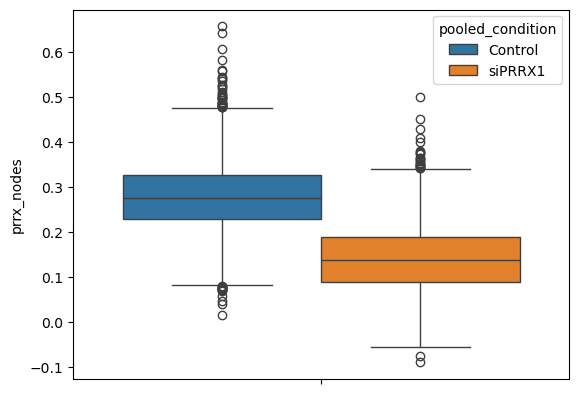

In [36]:
sc.tl.score_genes(
    fdata,
    gene_list=prrx_genes_robust,
    ctrl_size=len(prrx_genes_robust),
    score_name='prrx_nodes',
    layer='log_norm',
)

tmp = fdata.obs[['pooled_condition', 'prrx_nodes']].copy()
tmp.head()

display(tmp.groupby('pooled_condition', observed=True)['prrx_nodes'].describe())

sns.boxplot(
    data=tmp,
    y='prrx_nodes',
    hue='pooled_condition',
)

plt.show()